# 使用示例

## 数据准备
psychometric要求输入是一个`n_subject x n_item`的pd.DataFrame，  
列名随意，但每一列需要是一个item，这里我们用内建函数生成200个被试，80道题目的5因子数据

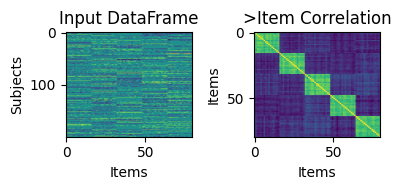

In [2]:
from psychometric.utils import generate_data
from matplotlib import pyplot as plt

data = generate_data(n_samples=200, n_items=80, n_factors=5, random_seed=42)
data  # n_subjects x n_items DataFrame

fig, axes = plt.subplots(1, 2, figsize=(4, 2))
for ax, img, title, (xlab, ylab) in [
    (axes[0], data, "Input DataFrame", ("Items", "Subjects")),
    (axes[1], data.corr(), ">Item Correlation", ("Items", "Items")),
]:
    ax.imshow(img, cmap="viridis", aspect="auto")
    ax.set(title=title, xlabel=xlab, ylabel=ylab)
fig.tight_layout()
plt.show()

## 题项分析  
部分，也有部分可以在因子与信度分析内

In [3]:
from psychometric import ItemAnalysis

ia = ItemAnalysis(data)
ia_result = ia.analyze()
print(f"item指标: {ia_result.keys()}")

item指标: dict_keys(['difficulty', 'citc', 'extreme_group', 'summary'])


In [4]:
ia_result["summary"]

,item,difficulty,level,citc,quality,difference,significant,discrimination,recommendation
0,Q1,0.475000,中,0.348294,良好,0.462963,True,优秀,保留
1,Q2,0.467500,中,0.299068,可接受,0.500000,True,优秀,考虑修改
2,Q3,0.447500,中,0.277061,可接受,0.462963,True,优秀,考虑修改
3,Q4,0.640000,中,0.293378,可接受,0.518519,True,优秀,考虑修改
4,Q5,0.628333,中,0.305394,良好,0.555556,True,优秀,保留
...,...,...,...,...,...,...,...,...,...
75,Q76,0.301667,中,0.409116,优秀,0.629630,True,优秀,保留
76,Q77,0.316667,中,0.395270,良好,0.629630,True,优秀,保留
77,Q78,0.313333,中,0.361828,良好,0.500000,True,优秀,保留
78,Q79,0.303333,中,0.296451,可接受,0.407407,True,优秀,考虑修改


## 信度分析

In [5]:
from psychometric import Reliability

rel = Reliability(data)
rel_result = rel.analyze()
print(f"信度指标: {rel_result.keys()}")

信度指标: dict_keys(['cronbach_alpha', 'alpha_if_deleted', 'split_half', 'omega'])


### alpha信度

In [6]:
rel_result["cronbach_alpha"]

{'alpha': np.float64(0.9231453987028012),
 'n_items': 80,
 'n_samples': 200,
 'quality': '优秀',
 'standardized_alpha': np.float64(0.9231465916683137)}

### omega信度

In [7]:
rel_result["omega"]

{'omega_total': np.float64(0.8795071761542845),
 'n_factors': 1,
 'quality': '良好'}

### 分半信度

In [8]:
rel_result["split_half"]

{'method': 'even-odd',
 'half1_alpha': np.float64(0.8477386154572809),
 'half2_alpha': np.float64(0.8521508181377602),
 'correlation': np.float64(0.9382498374872311),
 'spearman_brown': np.float64(0.9681412781167456),
 'quality': '优秀'}

### 留一信度

In [9]:
rel_result["alpha_if_deleted"]

,item,alpha_if_deleted,alpha_change,recommendation,original_alpha
0,Q1,0.922251,-0.000894,保留,0.923145
1,Q2,0.922526,-0.000620,保留,0.923145
2,Q3,0.922659,-0.000486,保留,0.923145
3,Q4,0.922590,-0.000556,保留,0.923145
4,Q5,0.922513,-0.000632,保留,0.923145
...,...,...,...,...,...
75,Q76,0.921856,-0.001290,保留,0.923145
76,Q77,0.921950,-0.001196,保留,0.923145
77,Q78,0.922163,-0.000982,保留,0.923145
78,Q79,0.922535,-0.000610,保留,0.923145


## 效度

In [10]:
from psychometric import Validity

val = Validity(data)
val_result = val.analyze()
print(f"效度指标: {val_result.keys()}")

/Users/zgh/Desktop/workingdir/psychometric_utils/.venv/lib/python3.12/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


效度指标: dict_keys(['efa', 'ave_cr', 'discriminant_validity'])


### 探索性FA

默认选择特征值大于1的因子，也可以传`n_factors`到`Validity.efa(n_factors)`计算

In [11]:
efa = val_result["efa"]
print(f"指标：{efa.keys()}")

指标：dict_keys(['n_factors', 'loadings', 'variance', 'communalities', 'kmo', 'bartlett', 'factor_structure', 'rotation', 'method'])


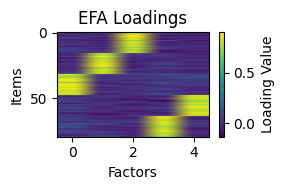

In [12]:
fig, ax = plt.subplots(figsize=(3, 2))
mat = efa["loadings"]
cax = ax.imshow(mat, cmap="viridis", aspect="auto")
ax.set(title="EFA Loadings", xlabel="Factors", ylabel="Items")
fig.colorbar(cax, ax=ax, label="Loading Value")
plt.tight_layout()
plt.show()

### 验证性FA

In [13]:
struct = {
    "O": [f"Q{i}" for i in range(1, 17)],
    "C": [f"Q{i}" for i in range(17, 33)],
    "E": [f"Q{i}" for i in range(33, 49)],
    "A": [f"Q{i}" for i in range(49, 65)],
    "N": [f"Q{i}" for i in range(65, 81)],
}
cfa = val.cfa(struct)
cfa.keys()

dict_keys(['fit_indices', 'loadings', 'estimates', 'model', 'model_spec'])

#### 拟合情况

In [14]:
cfa["fit_indices"]

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,3070,3160,3763.604778,1.110223e-16,18157.694594,0.953753,0.792727,0.78665,0.792727,0.952397,0.033695,302.363952,863.077905,18.818024


#### Factor loadings

In [15]:
cfa["estimates"]

,lval,op,rval,Estimate,Std. Err,z-value,p-value
0,Q1,~,O,1.000000,-,-,-
1,Q2,~,O,1.104562,0.088425,12.491487,0.0
2,Q3,~,O,1.240157,0.087992,14.093951,0.0
3,Q4,~,O,1.324430,0.094921,13.952946,0.0
4,Q5,~,O,1.278740,0.095589,13.377483,0.0
...,...,...,...,...,...,...,...
170,Q78,~~,Q78,0.116118,0.012229,9.495469,0.0
171,Q79,~~,Q79,0.105641,0.011136,9.486145,0.0
172,Q8,~~,Q8,0.105177,0.011216,9.377198,0.0
173,Q80,~~,Q80,0.097943,0.010183,9.618539,0.0


如需要可视化结构方程，请安装`graphviz`

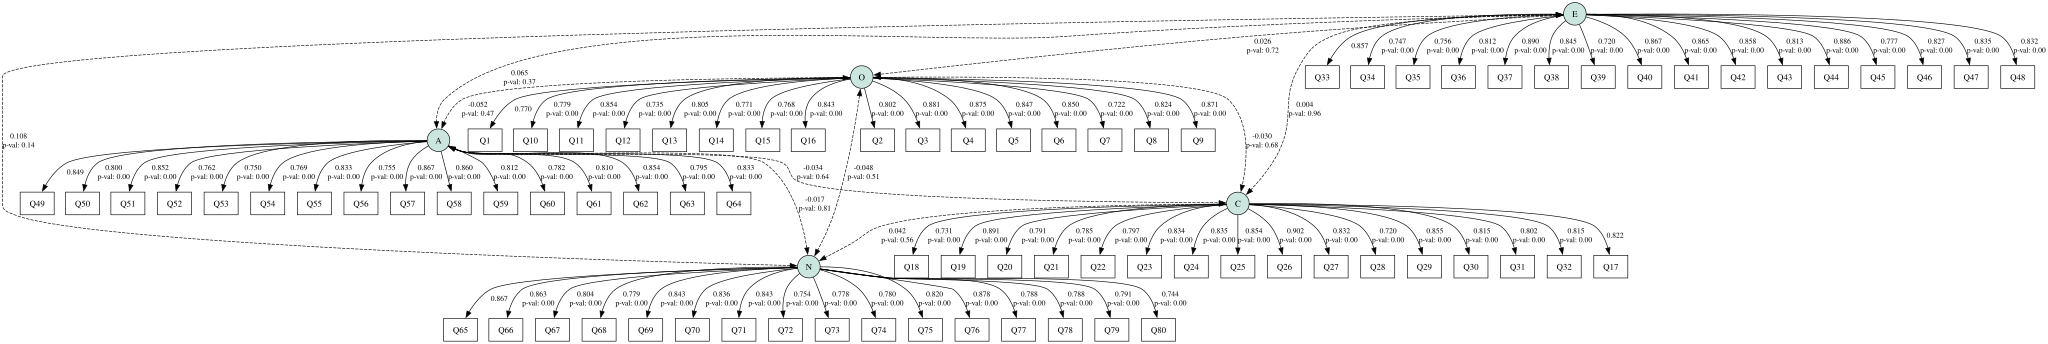

In [16]:
from semopy import semplot

semplot(cfa["model"], "cfa_example.png", std_ests=True, plot_covs=True)